# DCGAN on the SVHN Dataset



In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import glob
import imageio.v2 as imageio
import PIL

from scipy.io import loadmat
from tensorflow.keras import layers
from IPython import display

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install imageio
!pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-q009xi5v
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-q009xi5v
  Resolved https://github.com/tensorflow/docs to commit 7c3650212740204359d4ceae481abc79345541be
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-docs: filename=tensorflow_docs-2026.1.14.40212-py3-none-any.whl size=186922 sha256=746b00404c2a33b73dc0f57fff7d0a0ddced64b2bd10fee2b311073dba68234a
  Stored in directory: /tmp/pip-ephem-wheel-cache-p44tx524/wheels/3e/88/34/48d2789bc9d37b33ddce06bccc454fae0285e5396d0a5be9d9
Successfully built tensorflow-docs


## 1. Download and load the SVHN dataset

The original TensorFlow tutorial uses `tf.keras.datasets.mnist.load_data()`.  
For this assignment, I imported the SVHN url from Kaggle `.mat` files and load them with `scipy.io.loadmat`.


In [3]:

SVHN_TRAIN_URL = "http://ufldl.stanford.edu/housenumbers/train_32x32.mat"
SVHN_TEST_URL  = "http://ufldl.stanford.edu/housenumbers/test_32x32.mat"

train_mat_path = tf.keras.utils.get_file("train_32x32.mat", origin=SVHN_TRAIN_URL)
test_mat_path = tf.keras.utils.get_file("test_32x32.mat", origin=SVHN_TEST_URL)

train_raw = loadmat(train_mat_path)
test_raw = loadmat(test_mat_path)

train_images = train_raw["X"]         # shape: (32, 32, 3, N)
train_labels = train_raw["y"].flatten()

test_images = test_raw["X"]
test_labels = test_raw["y"].flatten()

# SVHN stores 0 as label 10
train_labels[train_labels == 10] = 0
test_labels[test_labels == 10] = 0

# Move image count to the first dimension: (N, 32, 32, 3)
train_images = np.transpose(train_images, (3, 0, 1, 2)).astype("float32")
test_images = np.transpose(test_images, (3, 0, 1, 2)).astype("float32")

print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

182040794/182040794 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
64275384/64275384 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train images shape: (73257, 32, 32, 3)
Train labels shape: (73257,)
Test images shape: (26032, 32, 32, 3)
Test labels shape: (26032,)


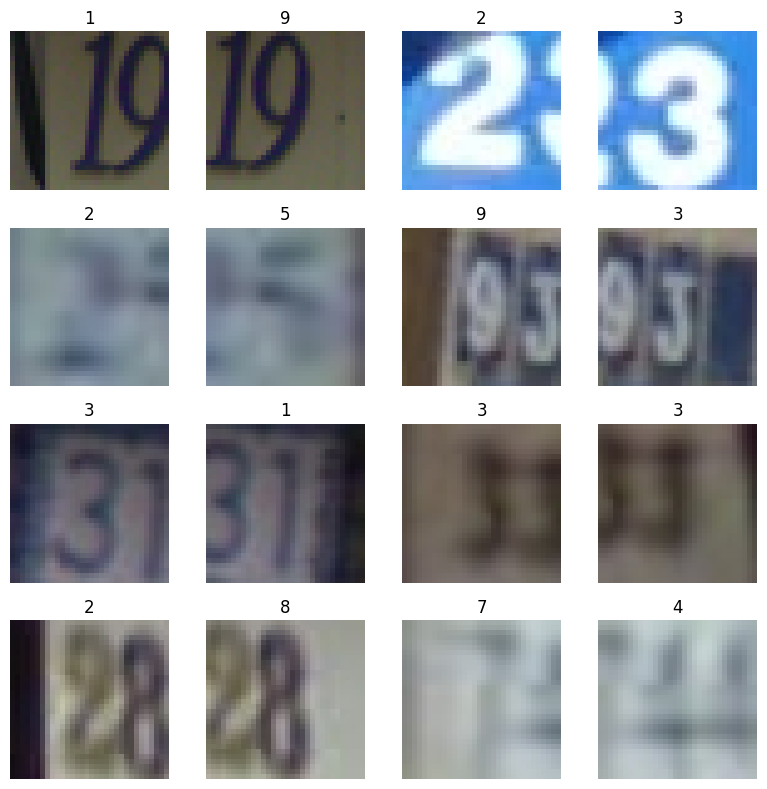

In [4]:

# Show sample training images
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(train_images[i].astype("uint8"))
    plt.title(int(train_labels[i]))
    plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Preprocess the images

The DCGAN tutorial normalizes MNIST images to the range `[-1, 1]`.  
We keep that same normalization because the generator uses `tanh` in the output layer.

In [5]:

train_images = (train_images - 127.5) / 127.5
test_images = (test_images - 127.5) / 127.5

BUFFER_SIZE = train_images.shape[0]
BATCH_SIZE = 256

train_dataset = (
    tf.data.Dataset.from_tensor_slices(train_images)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
)

print("Number of training batches:", len(list(train_dataset.take(5))))

Number of training batches: 5


## 3. Build the generator

The original tutorial generator ends with `28x28x1` because MNIST is grayscale.  
SVHN images are **32x32 RGB**, so the final output here is `32x32x3`.

In [6]:

noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(4 * 4 * 256, use_bias=False, input_shape=(noise_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((4, 4, 256)))
    assert model.output_shape == (None, 4, 4, 256)

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding="same", use_bias=False))
    assert model.output_shape == (None, 8, 8, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding="same", use_bias=False))
    assert model.output_shape == (None, 16, 16, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding="same", use_bias=False, activation="tanh"))
    assert model.output_shape == (None, 32, 32, 3)

    return model

generator = make_generator_model()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4096)           │       409,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 3)      │         4,800 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,455,552 (5.55 MB)

 Trainable params: 1,446,976 (5.52 MB)

 Non-trainable params: 8,576 (33.50 KB)

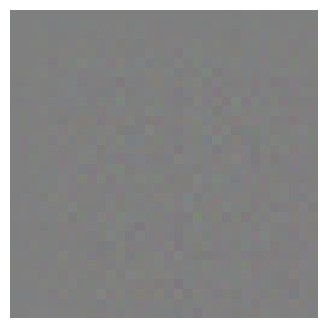

In [7]:

noise = tf.random.normal([1, noise_dim])
generated_image = generator(noise, training=False)[0]

plt.figure(figsize=(4, 4))
plt.imshow((generated_image * 127.5 + 127.5).numpy().astype("uint8"))
plt.axis("off")
plt.show()

## 4. Build the discriminator

The original tutorial discriminator accepts `28x28x1`.  
This version accepts **32x32x3** images.

In [8]:

def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same",
                            input_shape=[32, 32, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

discriminator = make_discriminator_model()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 217,985 (851.50 KB)

 Trainable params: 217,985 (851.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:

decision = discriminator(generated_image[tf.newaxis, ...], training=False)
print("Discriminator output for one generated image:", decision.numpy())

Discriminator output for one generated image: [[0.00662188]]


## 5. Define loss functions and optimizers
This section stays mostly the same as the original DCGAN tutorial.

In [10]:

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

## 6. Save checkpoints

In [11]:

checkpoint_dir = "./training_checkpoints_svhn"
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")

checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator,
)

## 7. Training loop
This remains very close to the TensorFlow tutorial, but now operates on `32x32x3` SVHN images.

In [12]:

EPOCHS = 50

In [13]:

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [14]:

gen_losses = []
disc_losses = []

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(6, 6))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        img = (predictions[i] * 127.5 + 127.5).numpy().astype("uint8")
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(f"Epoch {epoch}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"image_at_epoch_{epoch:04d}.png")
    plt.show()

def train(dataset, epochs):
    for epoch in range(1, epochs + 1):
        start = time.time()

        epoch_gen_losses = []
        epoch_disc_losses = []

        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            epoch_gen_losses.append(gen_loss.numpy())
            epoch_disc_losses.append(disc_loss.numpy())

        gen_losses.append(float(np.mean(epoch_gen_losses)))
        disc_losses.append(float(np.mean(epoch_disc_losses)))

        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch, seed)

        if (epoch % 5 == 0) or (epoch == epochs):
            checkpoint.save(file_prefix=checkpoint_prefix)

        print(f"Epoch {epoch}/{epochs} | "
              f"gen_loss={gen_losses[-1]:.4f} | "
              f"disc_loss={disc_losses[-1]:.4f} | "
              f"time={time.time()-start:.2f}s")

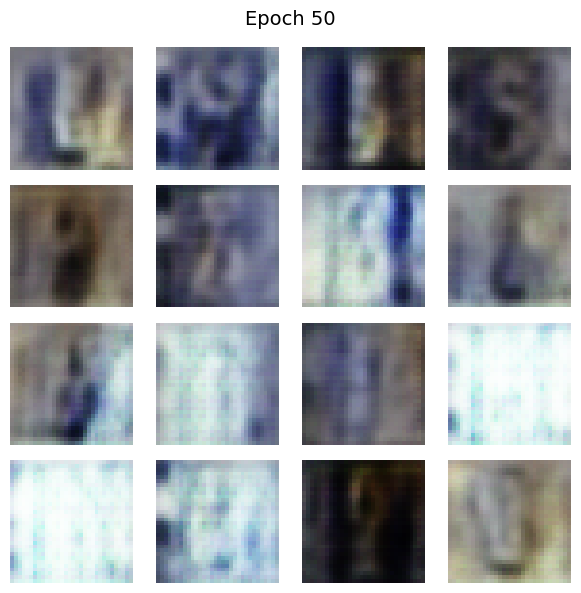

Epoch 50/50 | gen_loss=1.1062 | disc_loss=1.1844 | time=18.38s


In [15]:

train(train_dataset, EPOCHS)

## 8. Generate the final images

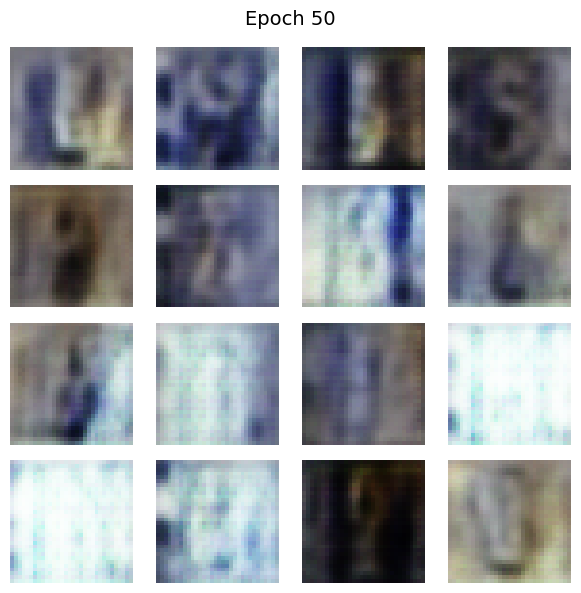

In [16]:

display.clear_output(wait=True)
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))
generate_and_save_images(generator, EPOCHS, seed)

## 9. Plot the training losses

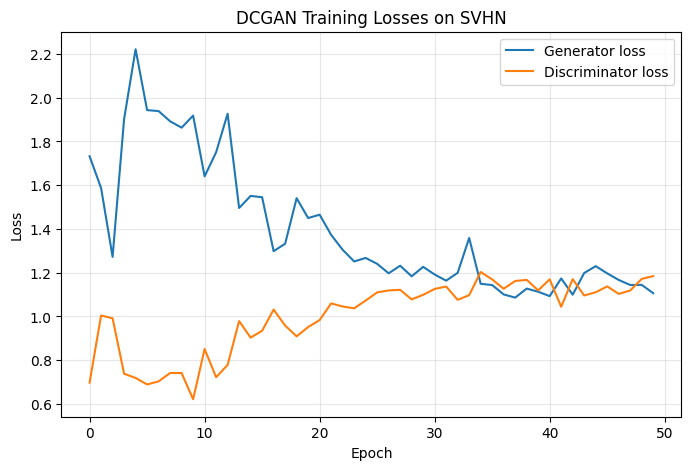

In [17]:

plt.figure(figsize=(8, 5))
plt.plot(gen_losses, label="Generator loss")
plt.plot(disc_losses, label="Discriminator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Losses on SVHN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Create a GIF of generated samples over time

In [18]:

anim_file = "dcgan_svhn.gif"

with imageio.get_writer(anim_file, mode="I") as writer:
    filenames = sorted(glob.glob("image_at_epoch_*.png"))
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

print("Saved GIF to", anim_file)

Saved GIF to dcgan_svhn.gif


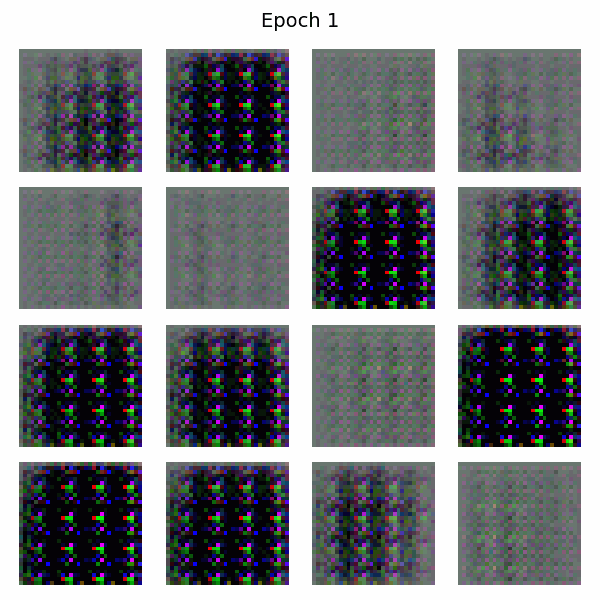

In [19]:
from IPython.display import Image
Image(filename='dcgan_svhn.gif')